### Comparing pairwise mutation rates for SNVs, short indels, and SVs across chromosomes and cenhaps

In [ ]:
# of short indels / aligned bases / avg array size
# of SNVs / aligned bases / avg array size
# of SVs / avg array size

In [1]:
import pandas as pd
from pathlib import Path

chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

output_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/per_cigar_mutation_rates")

dfs = []
for chrom in chromosomes:
    fp = output_dir / f"output_{chrom}.tsv"
    if fp.exists():
        dfs.append(pd.read_csv(fp, sep="\t"))

df = pd.concat(dfs, ignore_index=True)
df


,sample1,sample2,chr,avg_array_len,aligned_bases,n_snvs,n_snvs_per_aligned_base,n_snvs_per_aligned_base_per_avg_len,n_short_indels,n_short_indels_per_aligned_base,n_short_indels_per_aligned_base_per_avg_len,n_svs,n_svs_per_avg_len
0,HG02040.1,NA18983.1,chr1,4054652.5,3245747,1649,0.000508,1.253004e-10,110,0.000034,8.358424e-12,290,0.000072
1,HG00099.2,HG04204.1,chr1,3743784.0,3062338,1944,0.000635,1.695635e-10,141,0.000046,1.229859e-11,294,0.000079
2,HG002.2,HG01252.1,chr1,3893989.5,3463767,1864,0.000538,1.381982e-10,177,0.000051,1.312290e-11,244,0.000063
3,HG01099.1,NA20805.1,chr1,6613613.0,6199955,1266,0.000204,3.087496e-11,50,0.000008,1.219390e-12,236,0.000036
4,HG03041.1,HG03516.1,chr1,3535938.5,2891810,828,0.000286,8.097592e-11,44,0.000015,4.303068e-12,140,0.000040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,HG002.1,HG01261.1,chrY,308747.0,246302,327,0.001328,4.300085e-09,46,0.000187,6.049050e-10,15,0.000049
4757,HG00621.1,NA18945.1,chrY,304226.0,263387,31,0.000118,3.868753e-10,2,0.000008,2.495970e-11,4,0.000013
4758,CHM13.0,HG002.1,chrY,317335.5,317335,0,0.000000,0.000000e+00,1,0.000003,9.930323e-12,0,0.000000
4759,NA18952.1,NA19043.1,chrY,141483.5,106828,87,0.000814,5.756100e-09,6,0.000056,3.969724e-10,7,0.000049


In [2]:
clade_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/low_divergence_clades/max_dist_0.8_min_pairwise_0.95")

clade_dfs = []
for chrom in chromosomes:
    fp = clade_dir / chrom / "_clades.csv"
    if fp.exists():
        cdf = pd.read_csv(fp)
        cdf["chr"] = chrom
        clade_dfs.append(cdf)

clades_df = pd.concat(clade_dfs, ignore_index=True)
clades_df


,Clade,Sample,chr
0,Clade_1,CHM13.0,chr1
1,Clade_1,HG00099.2,chr1
2,Clade_1,HG00126.2,chr1
3,Clade_1,HG00235.1,chr1
4,Clade_1,HG00253.2,chr1
...,...,...,...
6734,Clade_8,HG01258.1,chrY
6735,Clade_9,NA20805.1,chrY
6736,Clade_9,NA20809.1,chrY
6737,Clade_10,HG01192.1,chrY


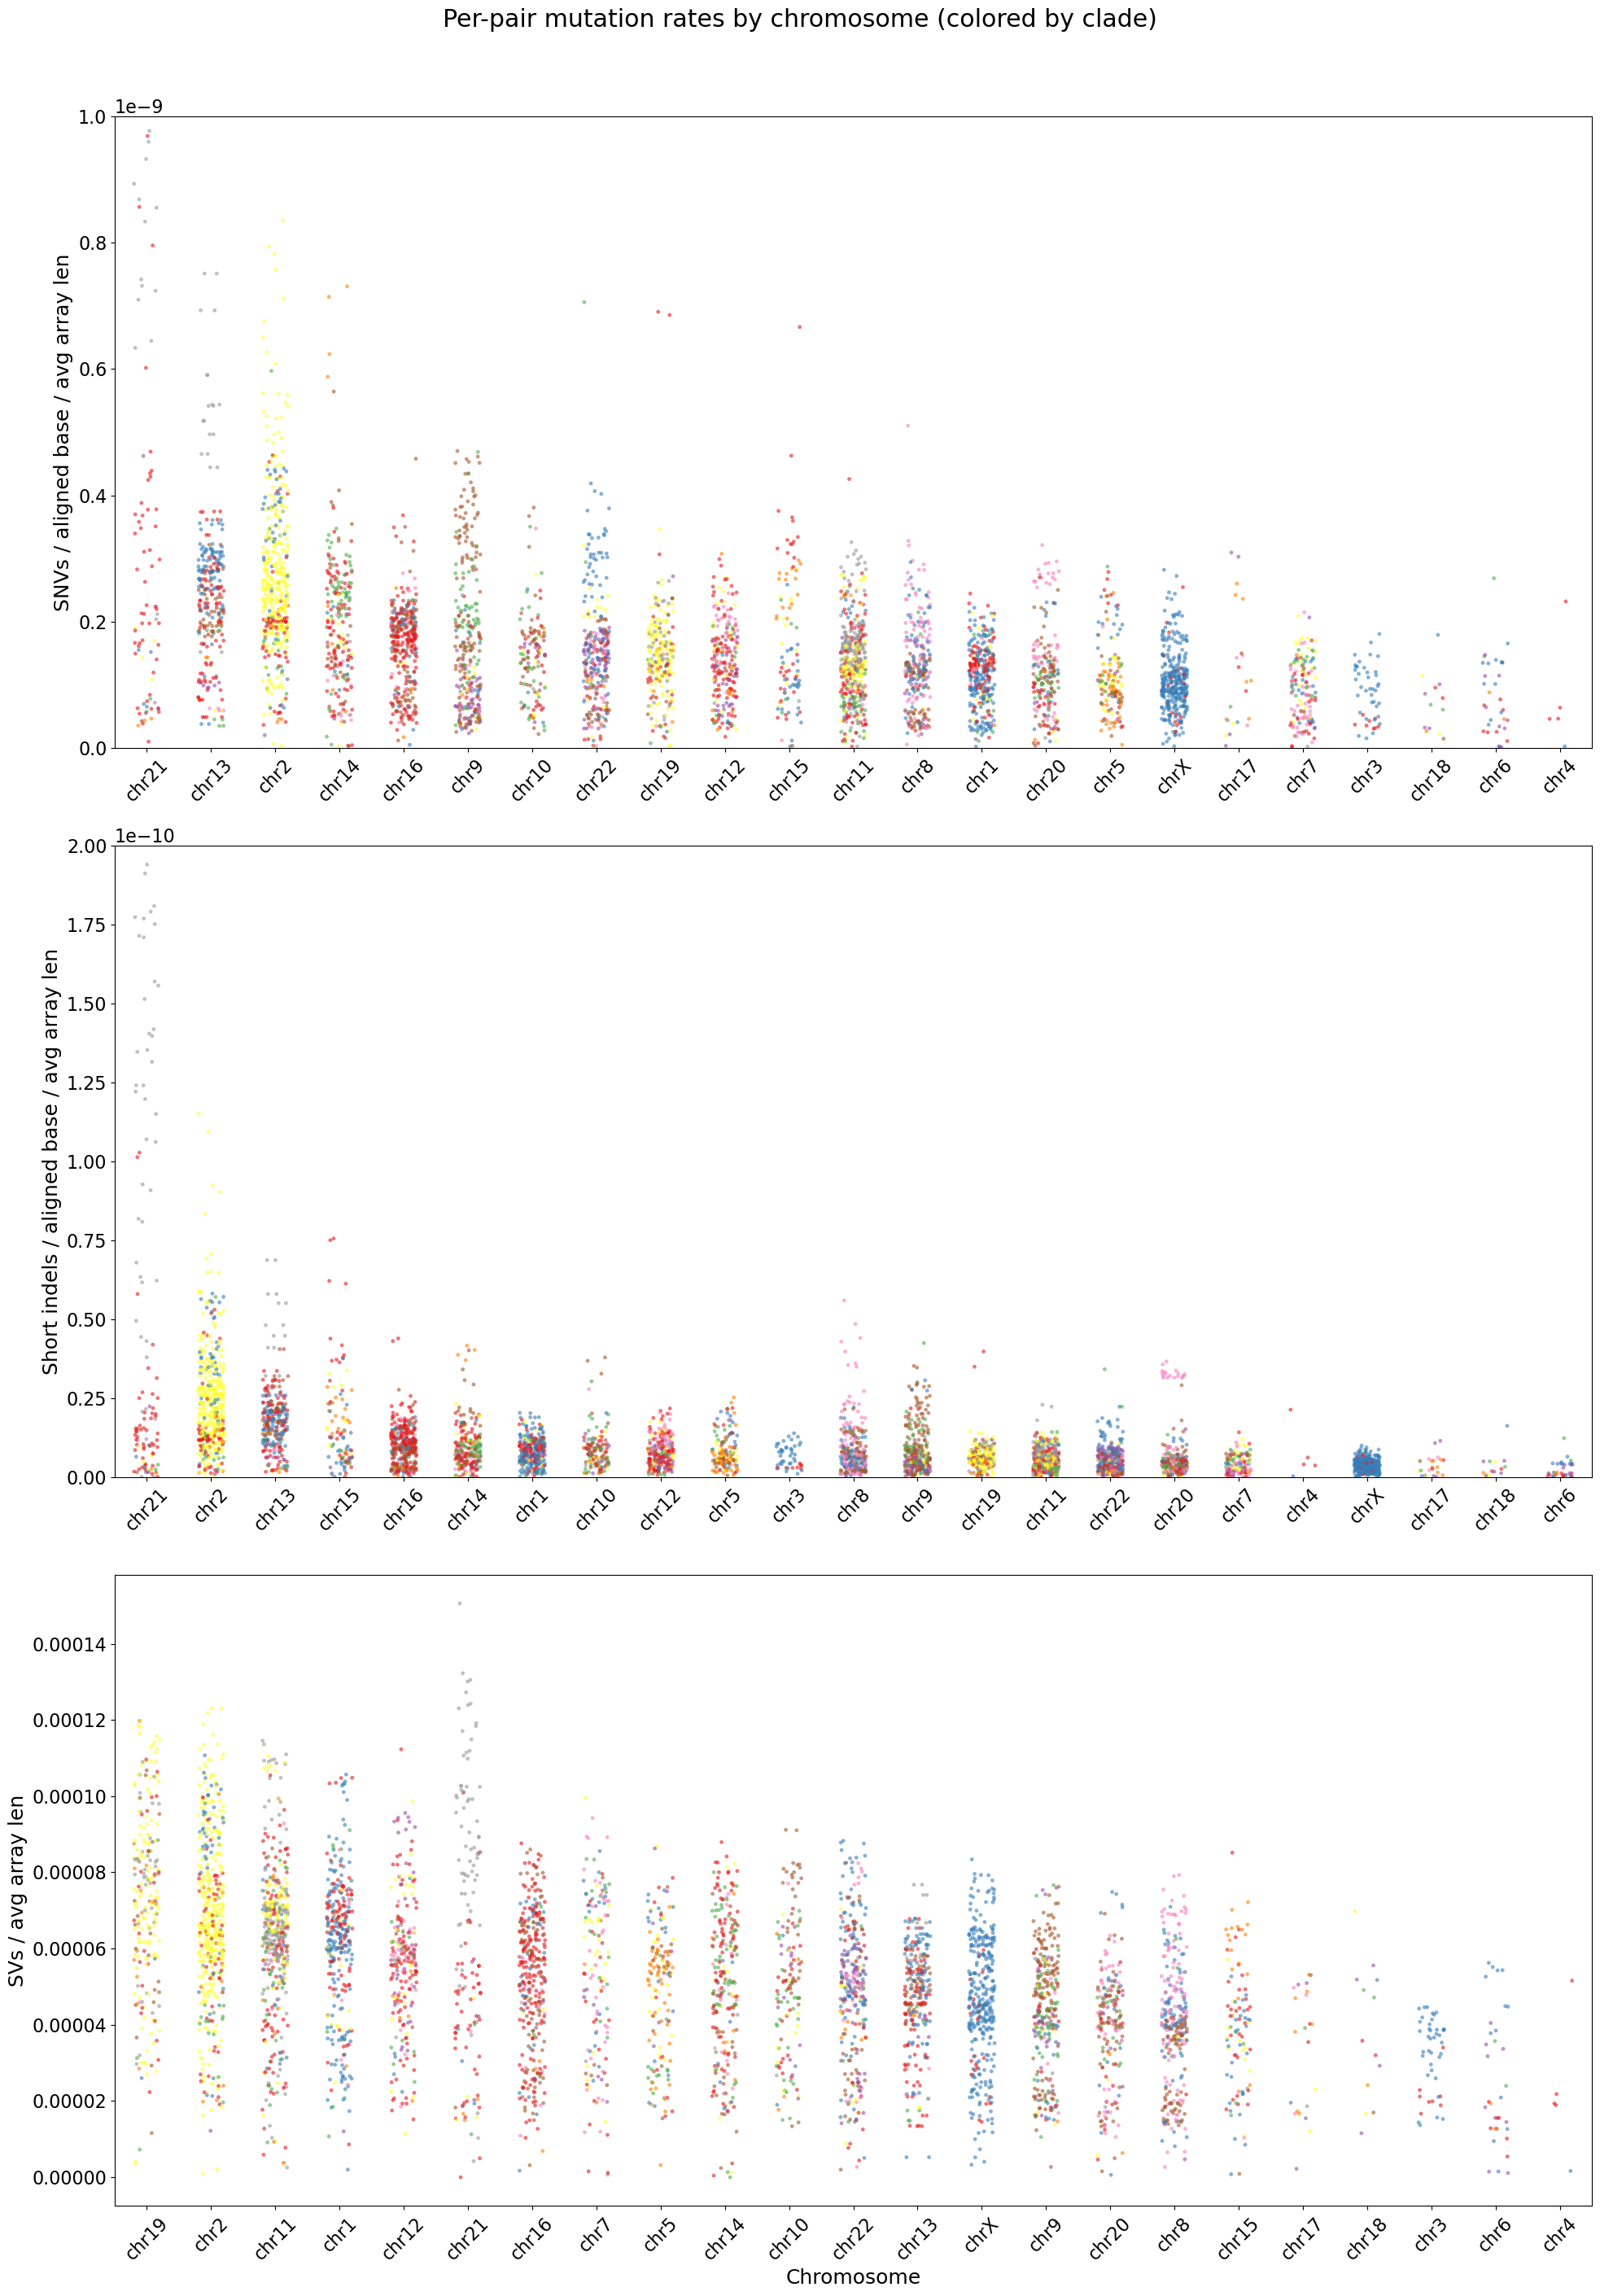

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Map each (Sample, chr) to its clade
clade_map = clades_df.set_index(["Sample", "chr"])["Clade"].to_dict()

# Assign clade to each pair
pair_clades = []
for _, row in df.iterrows():
    c1 = clade_map.get((row["sample1"], row["chr"]))
    c2 = clade_map.get((row["sample2"], row["chr"]))
    if c1 is not None and c2 is not None and c1 == c2:
        pair_clades.append(c1)
    else:
        #if c1 is not None and c2 is not None and c1 != c2:
            #print(f"WARNING: {row['sample1']} ({c1}) and {row['sample2']} ({c2}) in different clades on {row['chr']}")
        pair_clades.append("cross-clade")

df["pair_clade"] = pair_clades
df_plot = df[df["chr"] != "chrY"]


# Sort chromosomes by median SNV rate
metrics = [
    "n_snvs_per_aligned_base_per_avg_len",
    "n_short_indels_per_aligned_base_per_avg_len",
    "n_svs_per_avg_len",
]
titles = ["SNVs / aligned base / avg array len",
          "Short indels / aligned base / avg array len",
          "SVs / avg array len"]

chr_order = (df.groupby("chr")[metrics[0]]
             .median()
             .sort_values(ascending=False)
             .index.tolist())

chr_order = [c for c in chr_order if c != "chrY"]


# Build color palette: one color per clade, black for cross-clade
all_clades = sorted([c for c in df["pair_clade"].unique() if c != "cross-clade"])
clade_palette = dict(zip(all_clades, sns.color_palette("Set1", len(all_clades))))
clade_palette["cross-clade"] = (0, 0, 0)

plt.rcParams.update({"font.size": 18, "axes.labelsize": 18, "axes.titlesize": 20, "xtick.labelsize": 16, "ytick.labelsize": 16})
base_palette = sns.color_palette("Set1", 10)

fig, axes = plt.subplots(3, 1, figsize=(20, 28), sharex=False)

for ax, metric, title in zip(axes, metrics, titles):
    chr_order_metric = (df_plot.groupby("chr")[metric]
                        .median()
                        .sort_values(ascending=False)
                        .index.tolist())

    for xi, chrom in enumerate(chr_order_metric):
        chunk = df_plot[df_plot["chr"] == chrom]
        # Build per-chromosome clade palette
        local_clades = sorted([c for c in chunk["pair_clade"].unique() if c != "cross-clade"])
        local_palette = {c: base_palette[i % len(base_palette)] for i, c in enumerate(local_clades)}
        local_palette["cross-clade"] = (0, 0, 0)

        colors = [local_palette[c] for c in chunk["pair_clade"]]
        jitter = np.random.uniform(-0.2, 0.2, size=len(chunk))
        ax.scatter(xi + jitter, chunk[metric], c=colors, s=12, alpha=0.6, linewidth=0)

    ax.set_xticks(range(len(chr_order_metric)))
    ax.set_xticklabels(chr_order_metric, rotation=45)
    ax.set_ylabel(title)
    ax.set_xlabel("")
    ax.set_xlim(-0.5, len(chr_order_metric) - 0.5)

axes[0].set_ylim(0, 1e-9)
axes[1].set_ylim(0, 2e-10)
axes[-1].set_xlabel("Chromosome")
fig.suptitle("Per-pair mutation rates by chromosome (colored by clade)", y=1.01)
fig.tight_layout()
plt.show()



In [5]:
def remove_outliers(df, value_col, group_col="chr"):
    clean_df = pd.DataFrame()
    for chrom, group in df.groupby(group_col):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (group[value_col] >= Q1 - 1.5 * IQR) & (group[value_col] <= Q3 + 1.5 * IQR)
        clean_df = pd.concat([clean_df, group[mask]], ignore_index=True)
    return clean_df


/data/tmp/ipykernel_2514474/2522925249.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_2514474/2522925249.py:30: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/data/tmp/ipykernel_2514474/2522925249.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_2514474/2522925249.py:30: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/data/tmp/ipykernel_2514474/2522925249.py:30: FutureWarning: 

Passing `palette` without assigning `hue`

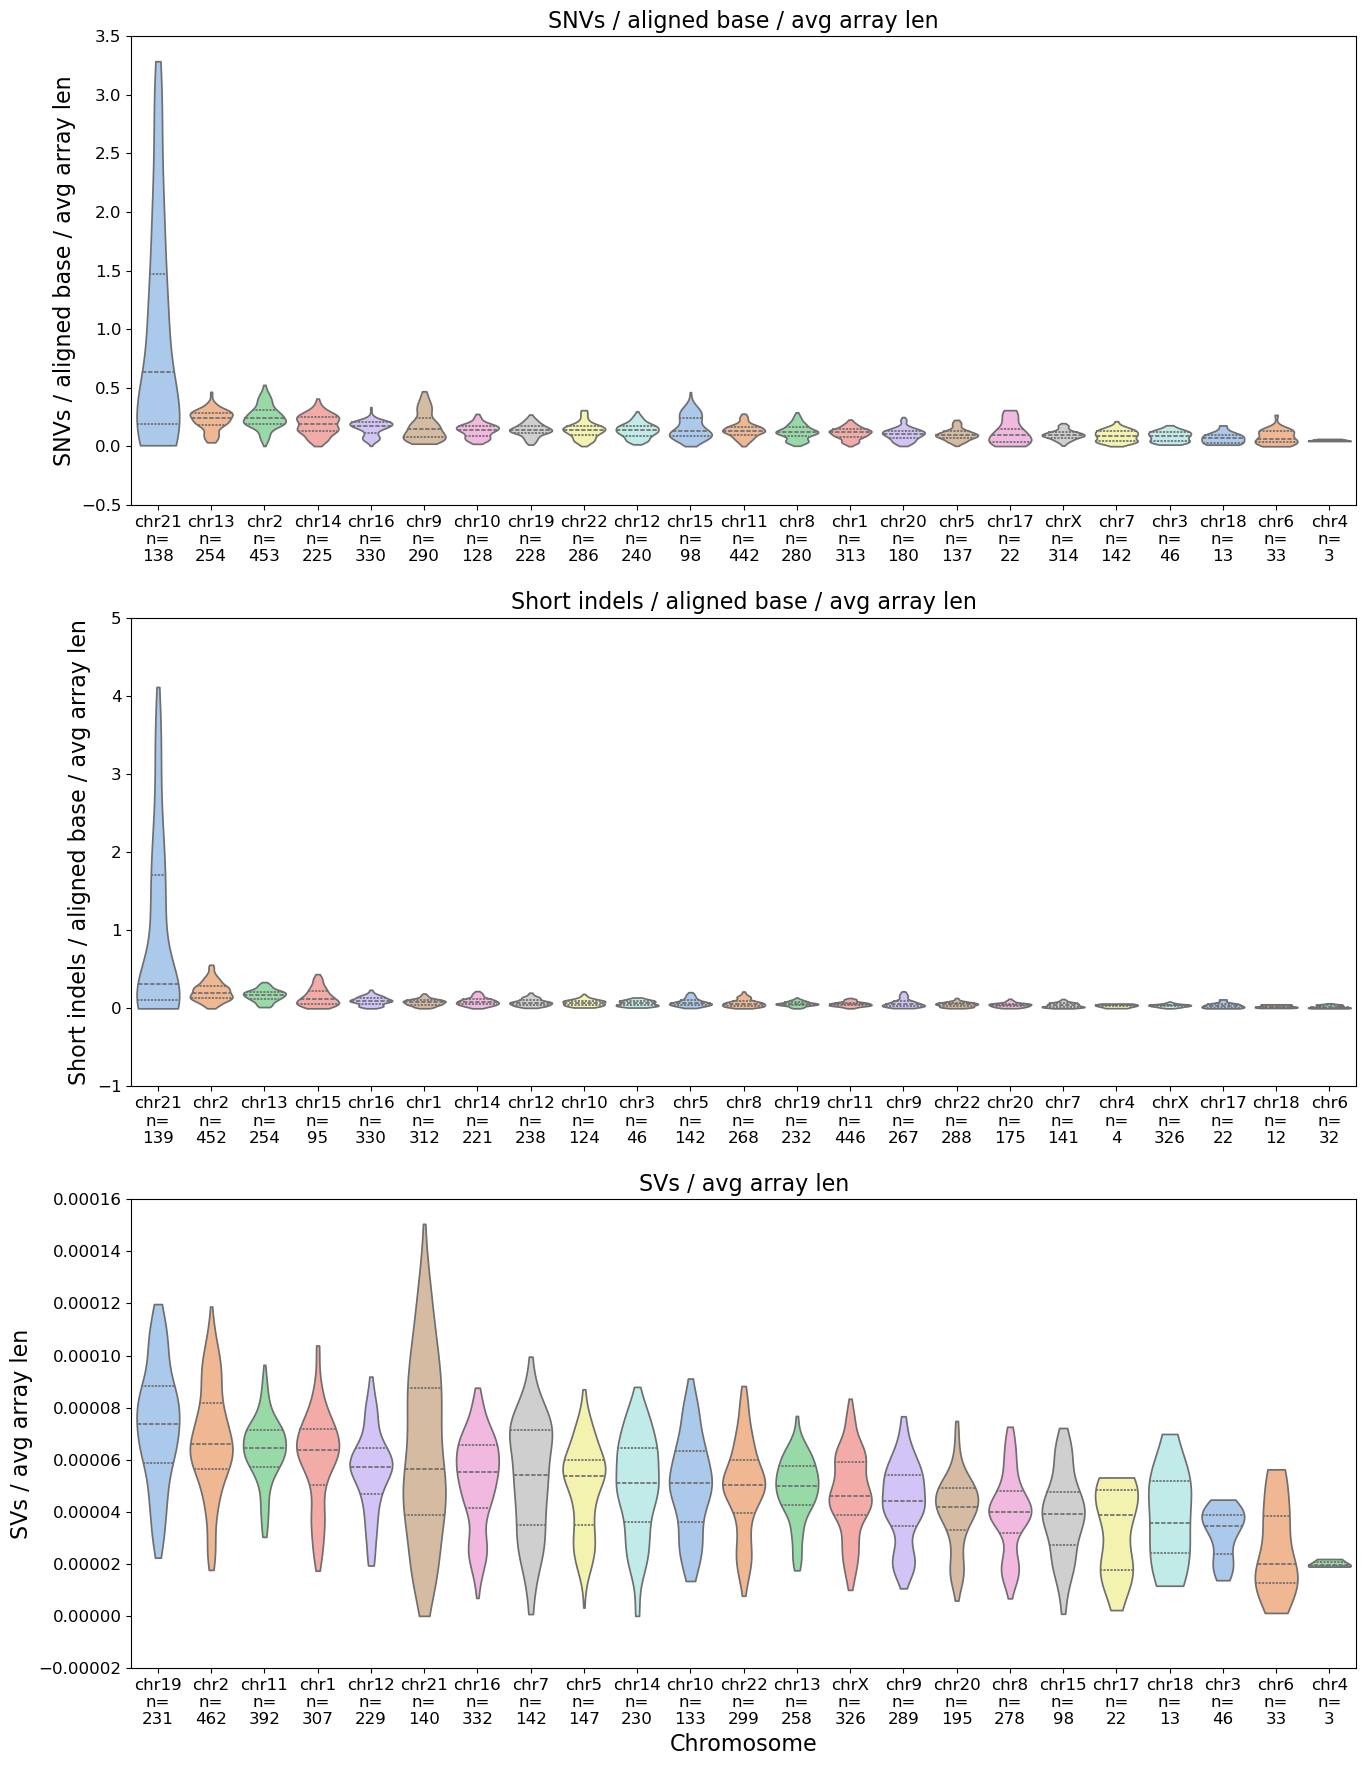

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#df_plot = df[df["chr"] != "chr21"]
df_plot = df[df["chr"] != "chrY"]

metrics = [
    "n_snvs_per_aligned_base_per_avg_len",
    "n_short_indels_per_aligned_base_per_avg_len",
    "n_svs_per_avg_len",
]
titles = ["SNVs / aligned base / avg array len",
          "Short indels / aligned base / avg array len",
          "SVs / avg array len"]

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, metric, title in zip(axes, metrics, titles):
    df_clean = remove_outliers(df_plot, value_col=metric)

    chr_order_metric = (df_clean.groupby("chr")[metric]
                        .median()
                        .sort_values(ascending=False)
                        .index.tolist())

    chr_counts = df_clean["chr"].value_counts()
    chr_labels = [f"{c}\nn=\n{chr_counts[c]}" for c in chr_order_metric]

    sns.violinplot(
        data=df_clean,
        x="chr",
        y=metric,
        order=chr_order_metric,
        inner="quartile",
        cut=0,
        scale="width",
        palette="pastel",
        ax=ax,
    )
    ax.set_xticks(range(len(chr_order_metric)))
    ax.set_xticklabels(chr_labels, rotation=0, fontsize=12)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel(title, fontsize=16)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)


#axes[0].set_ylim(0, 1e-9)
#axes[1].set_ylim(0, 2e-10)
axes[-1].set_xlabel("Chromosome", fontsize=16)
fig.tight_layout()
plt.show()


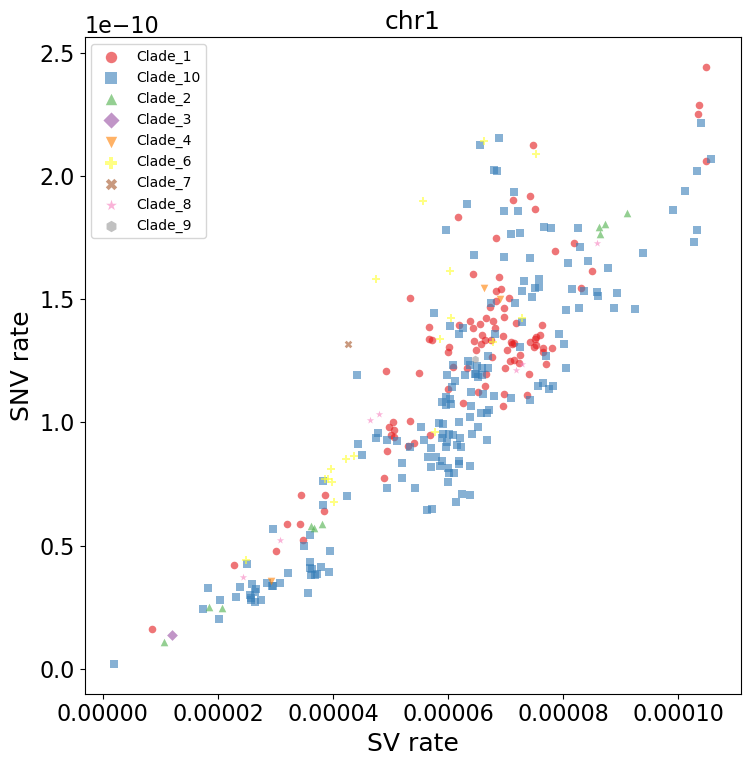

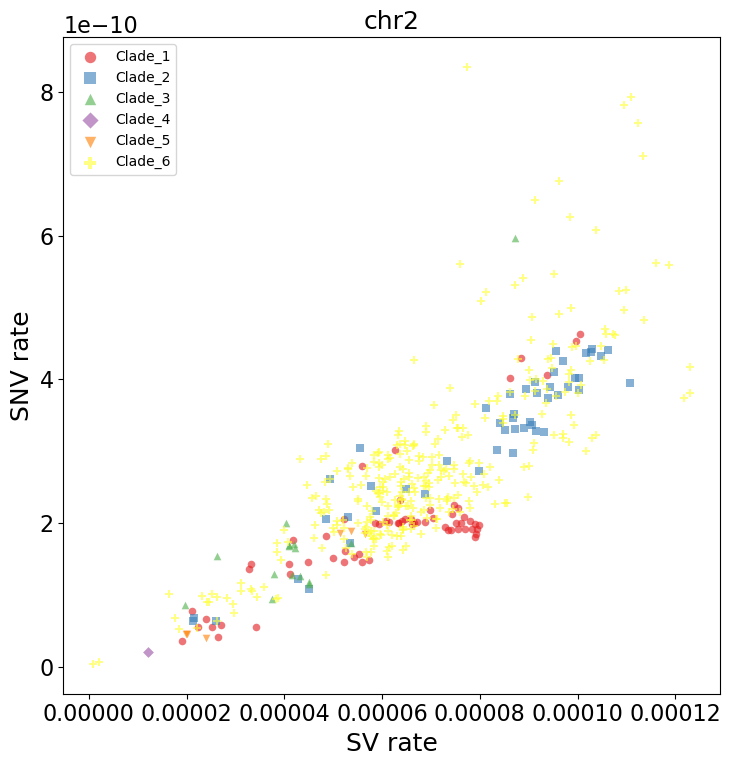

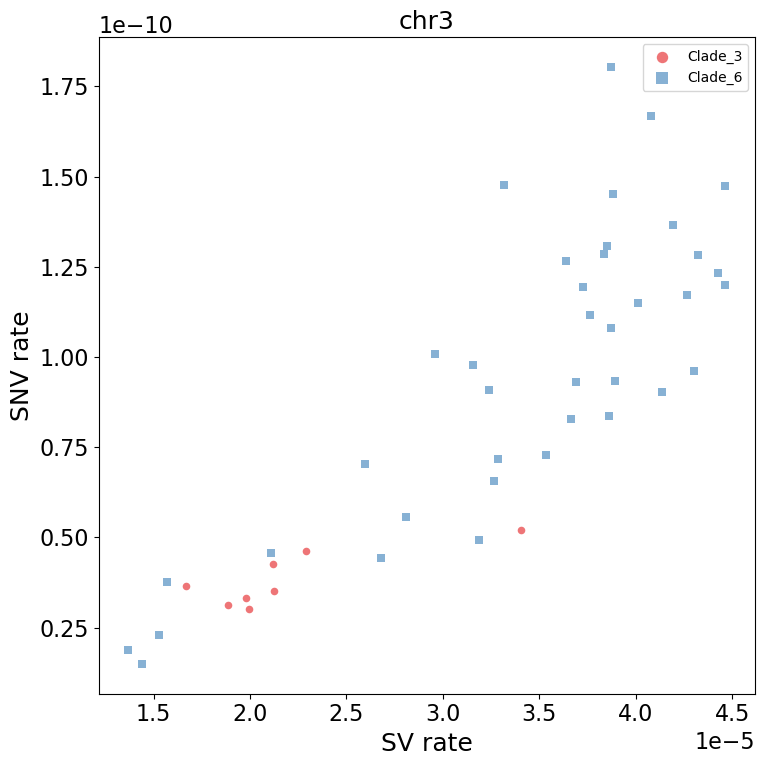

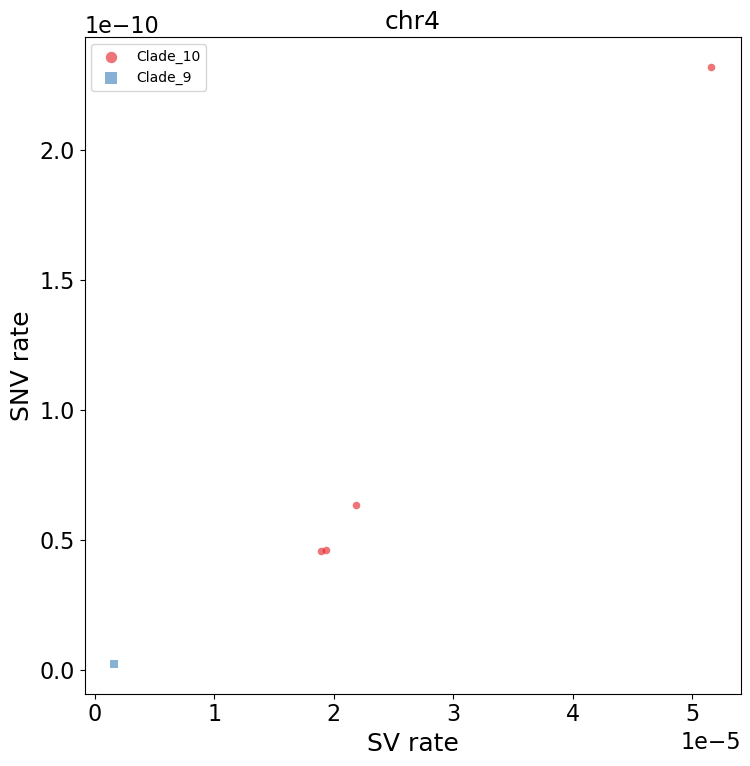

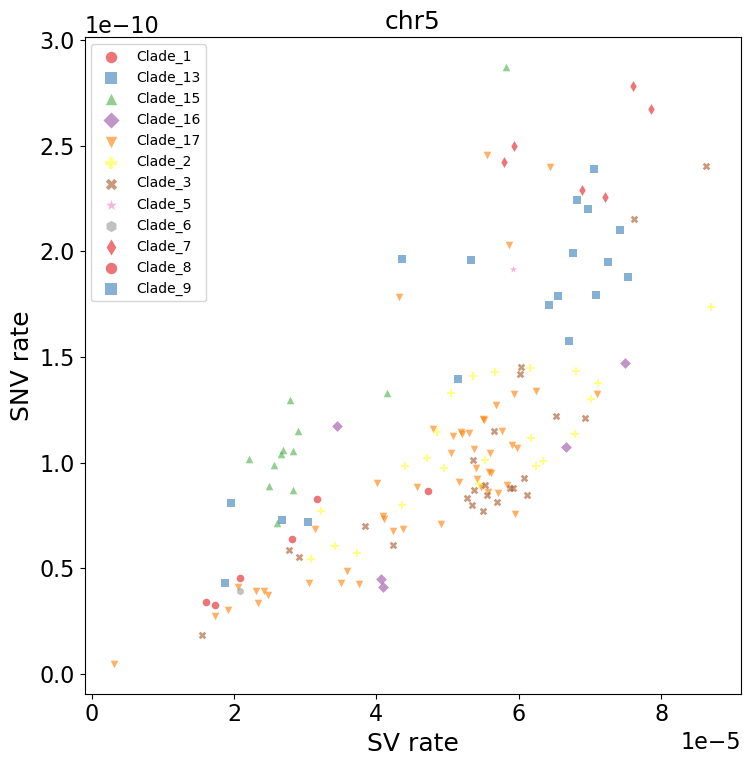

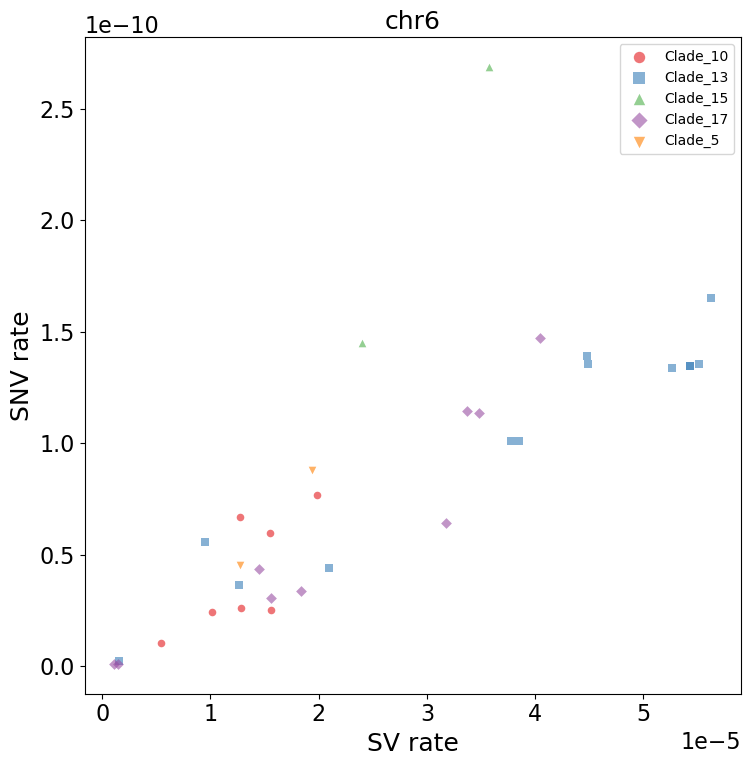

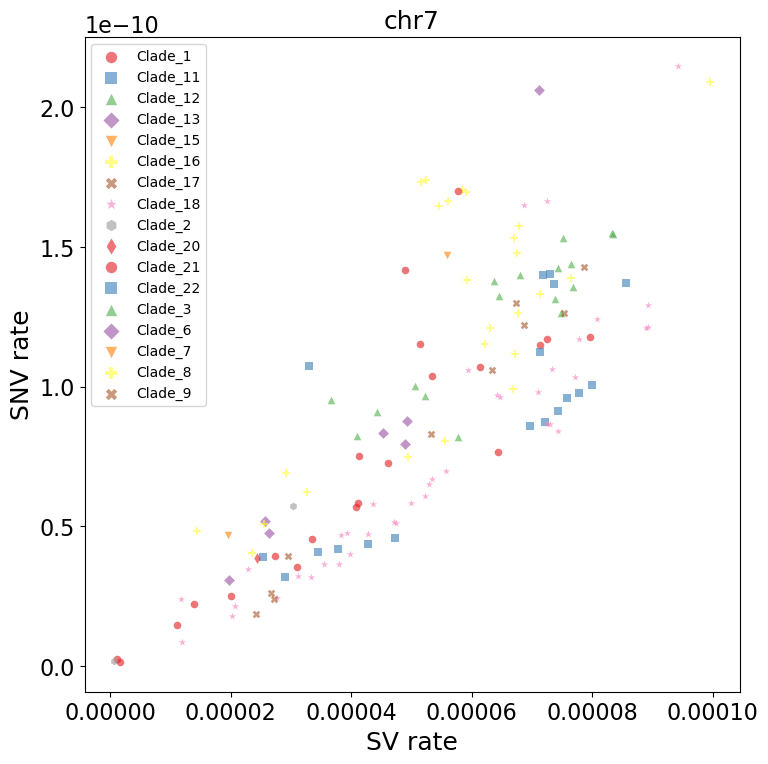

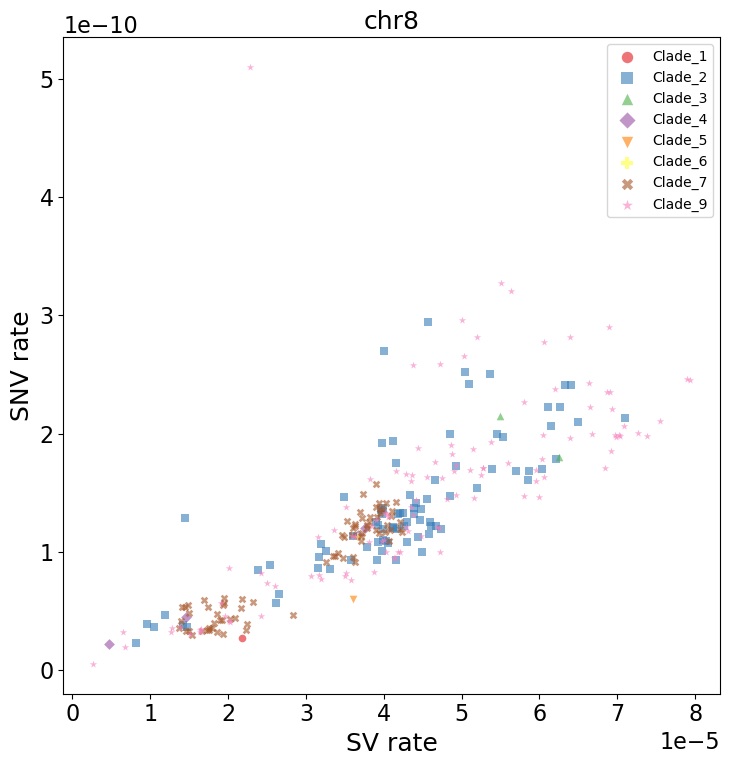

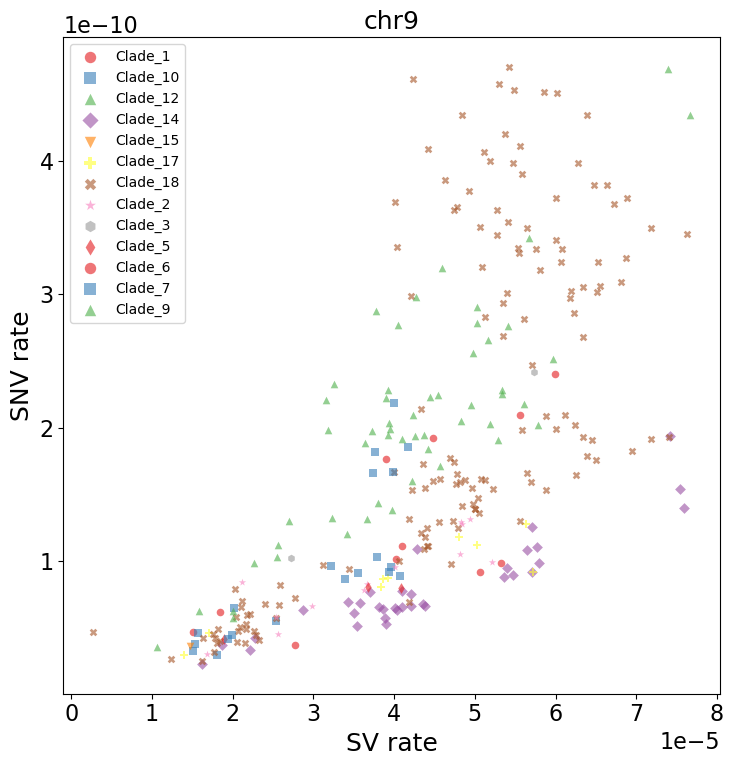

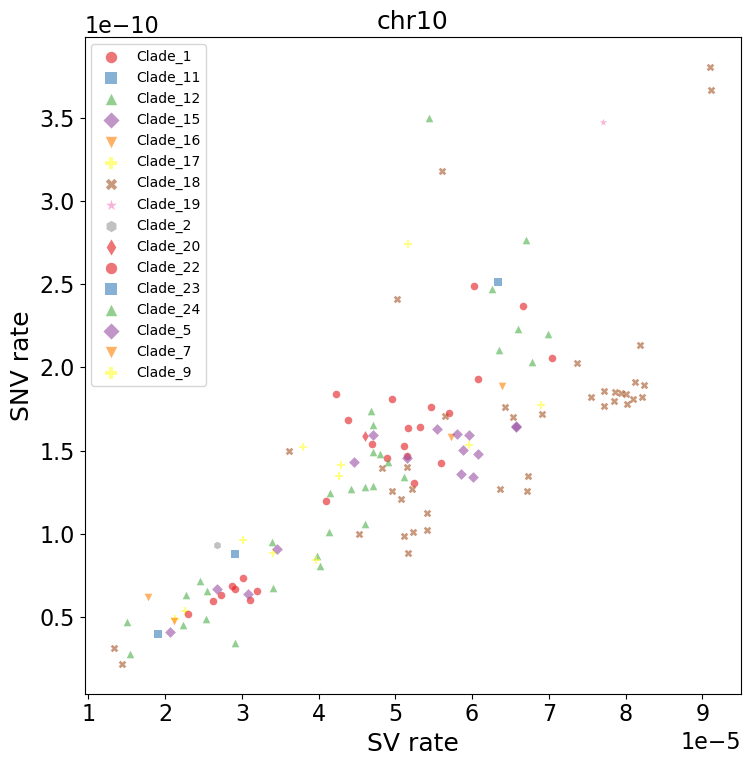

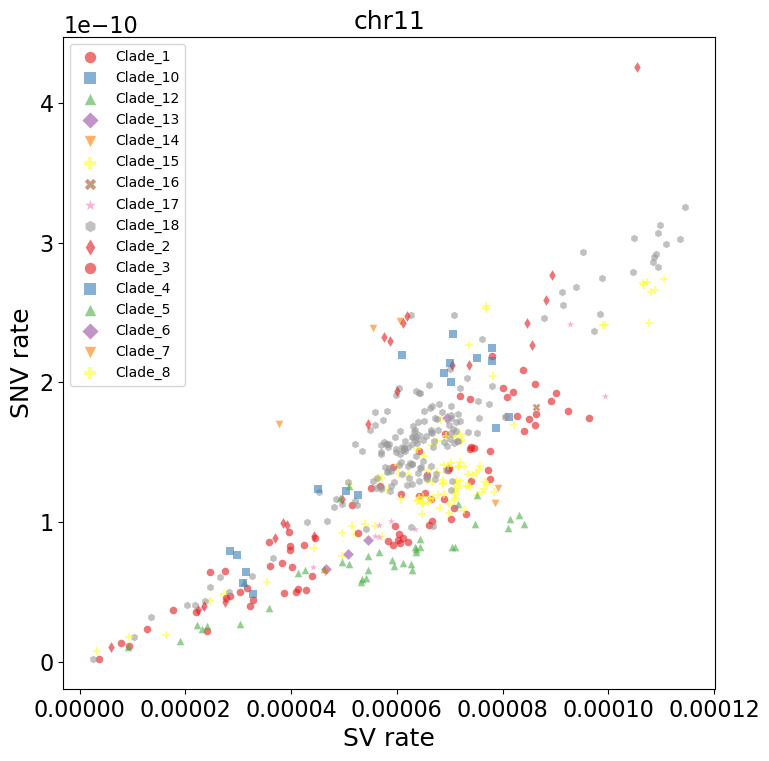

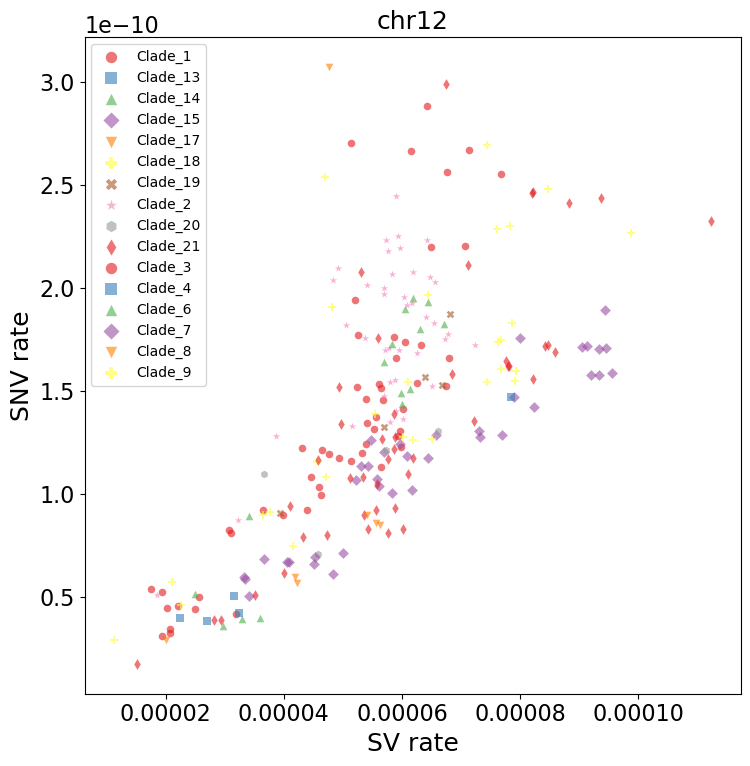

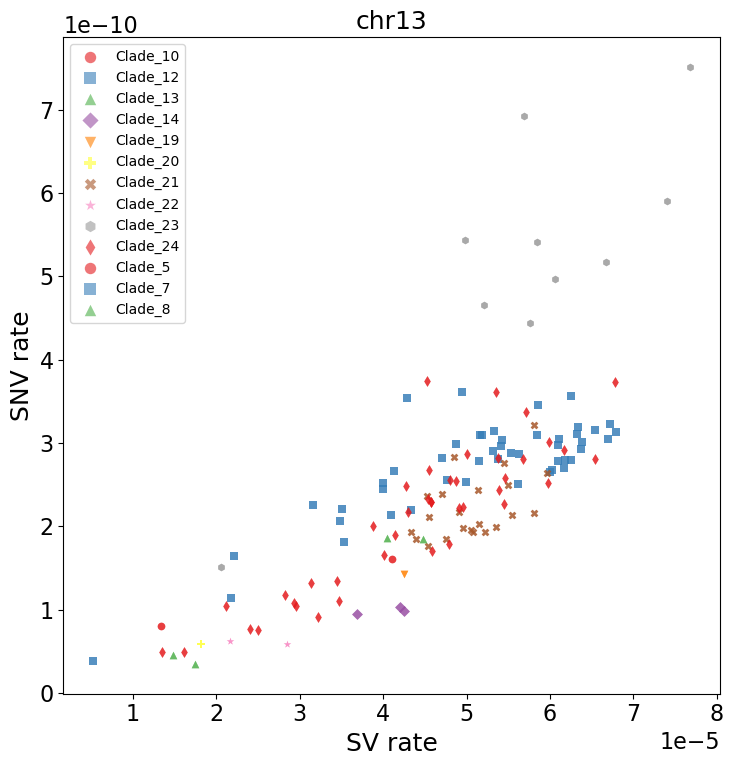

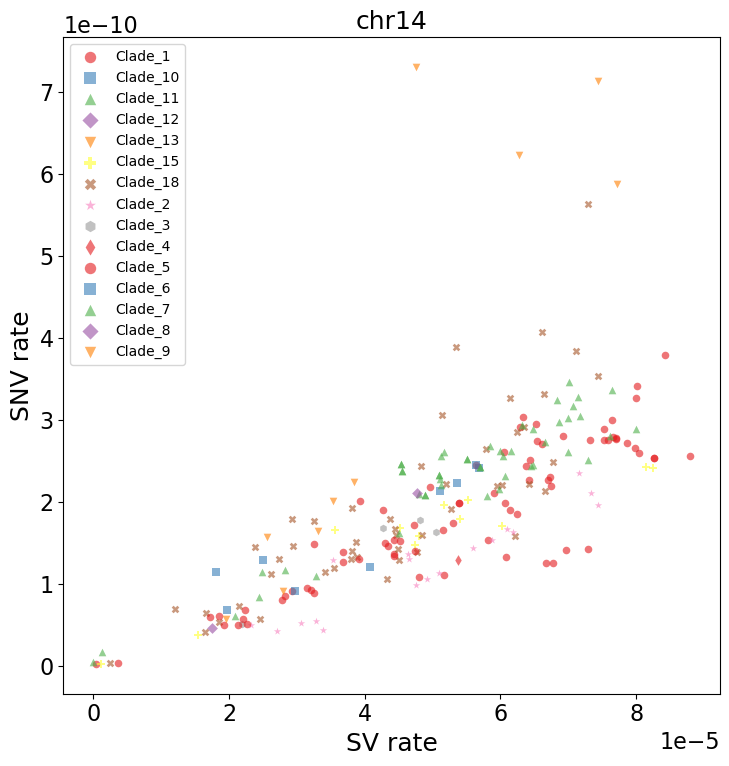

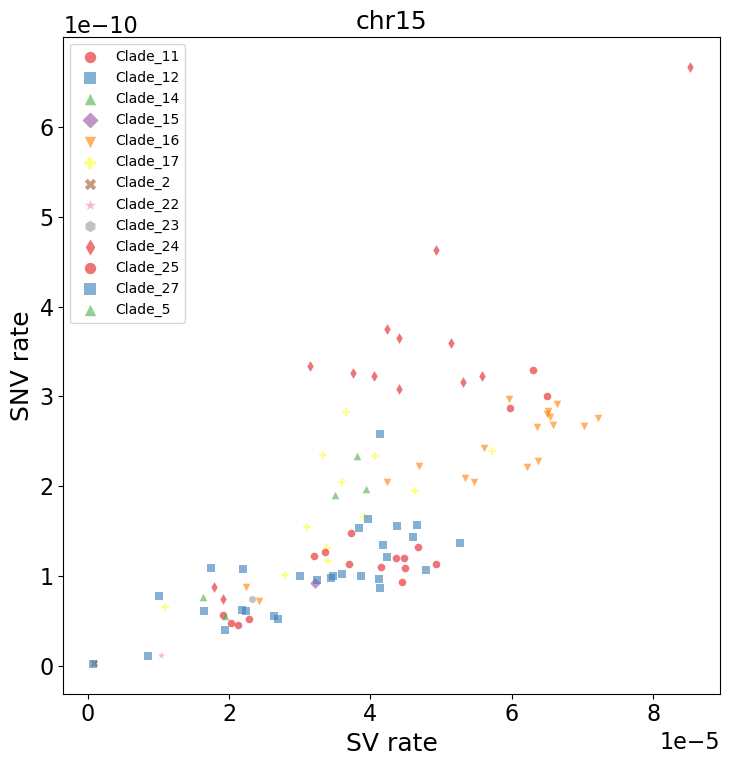

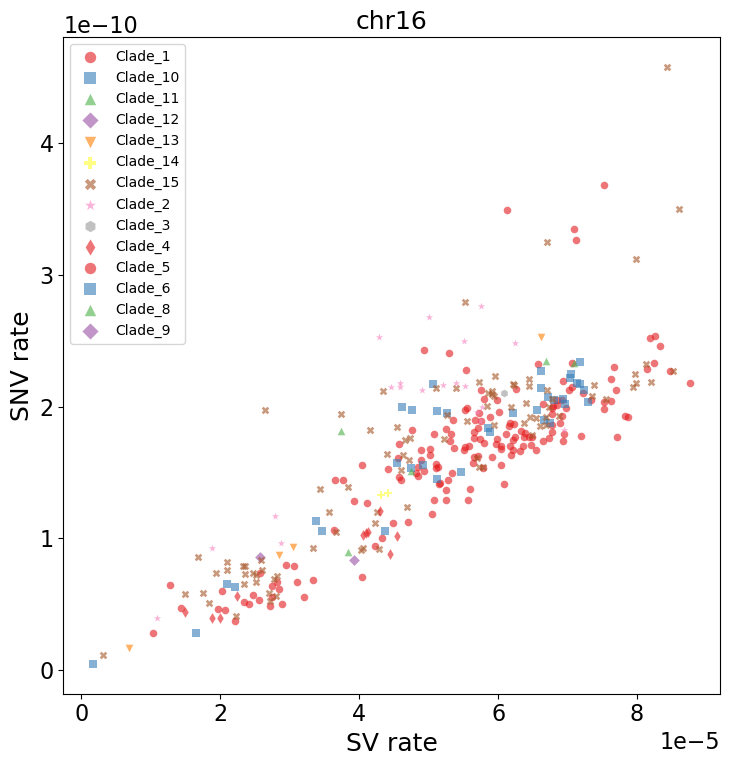

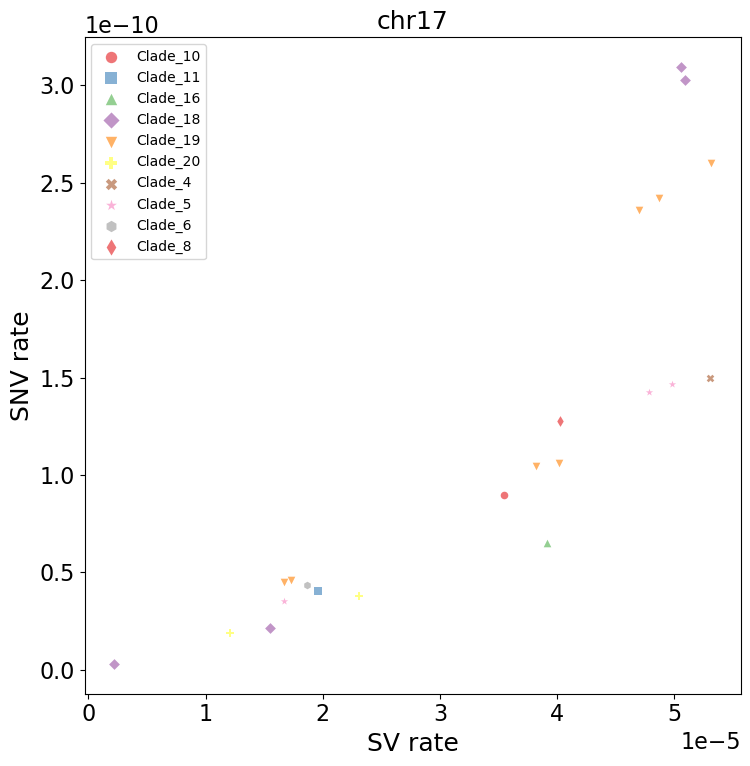

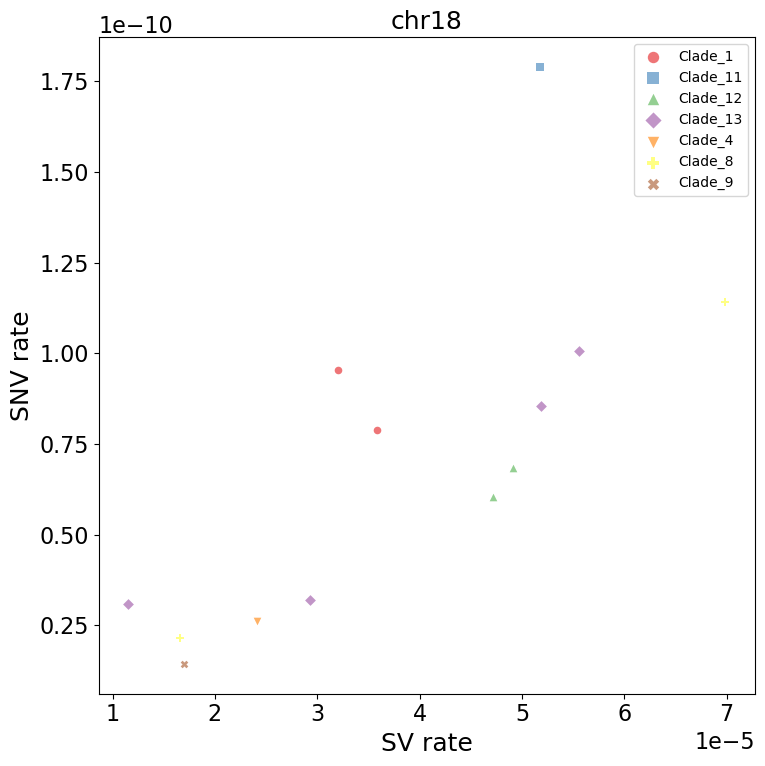

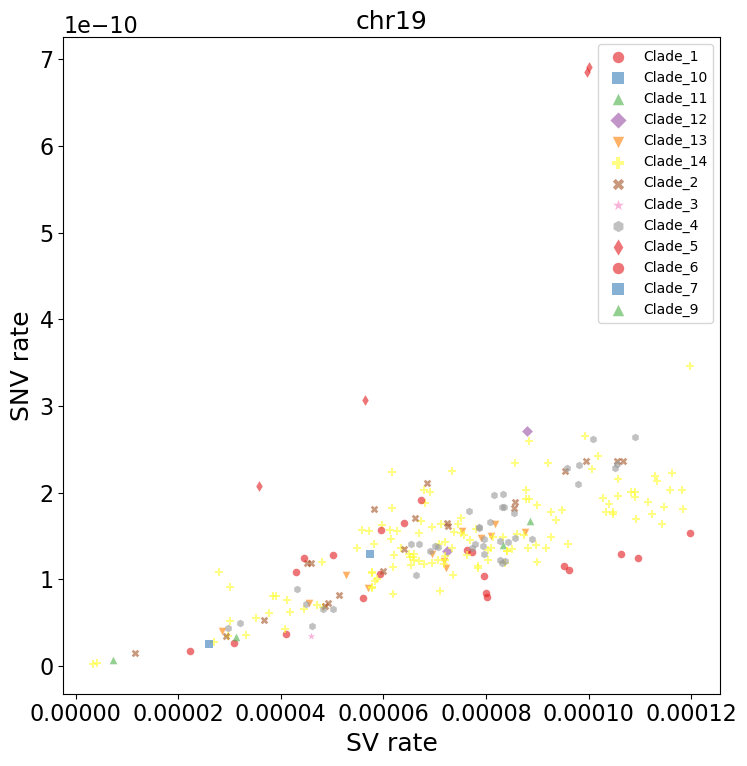

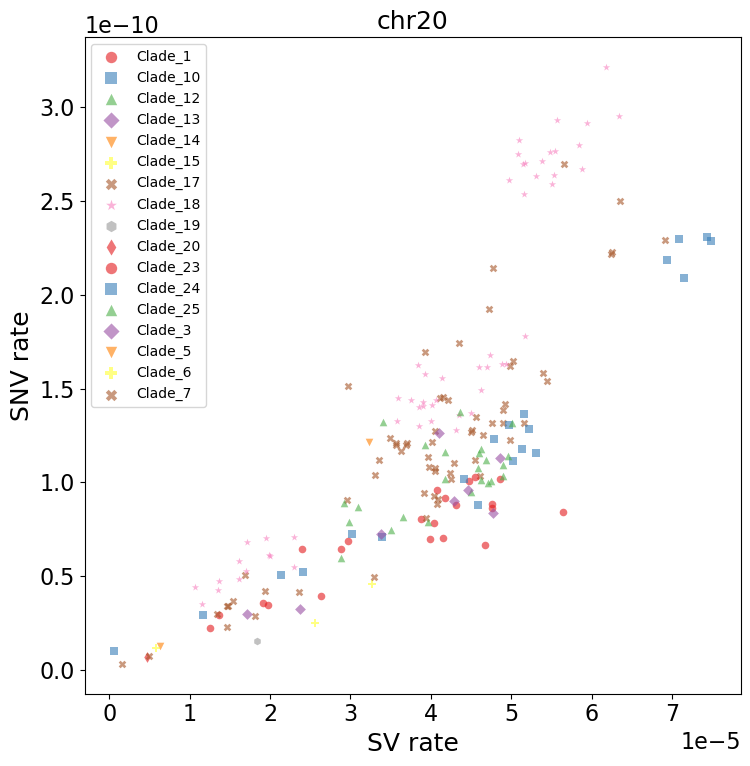

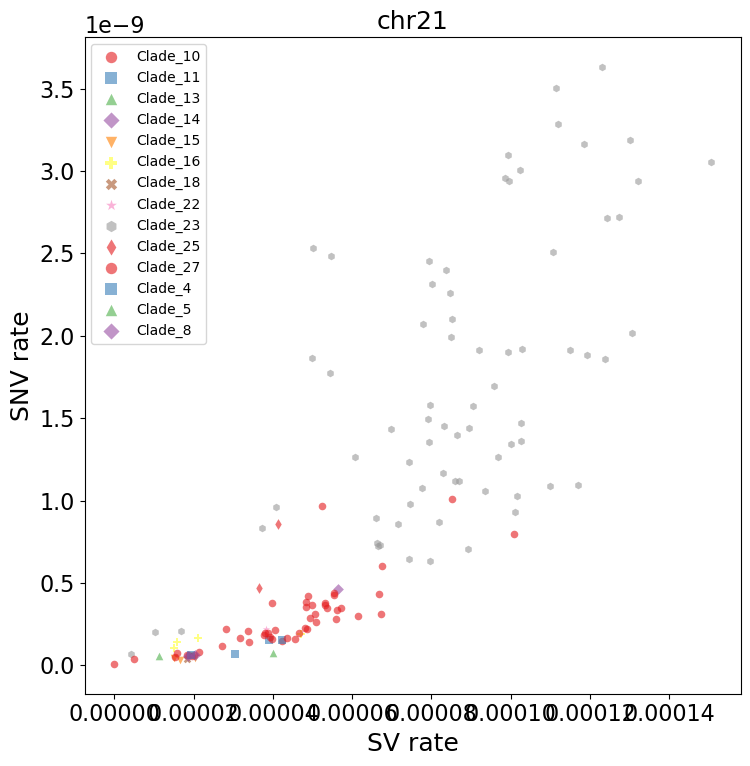

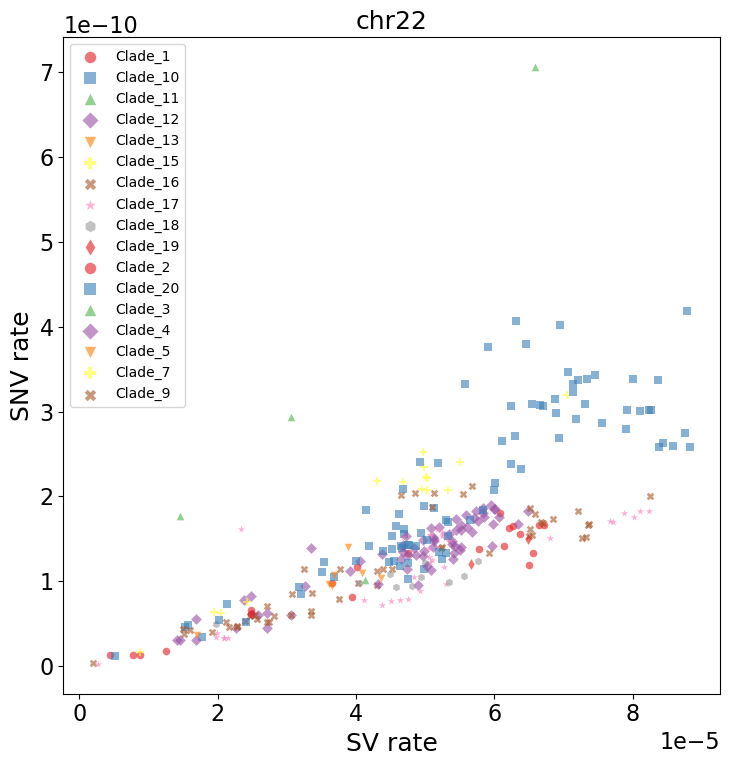

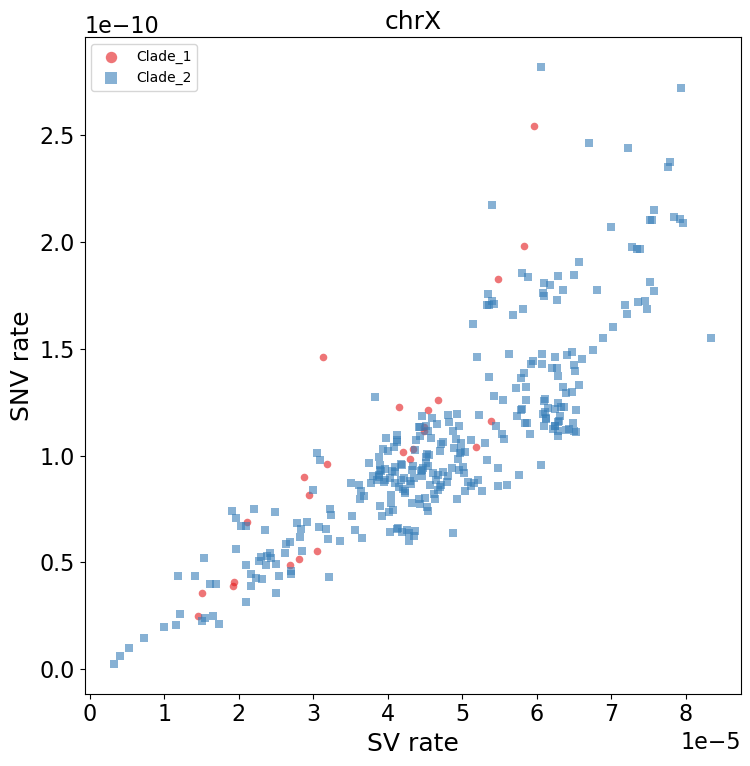

In [7]:
chrom_list = sorted(df_plot["chr"].unique(), key=lambda c: int(c.replace("chr", "")) if c.replace("chr", "").isdigit() else 100 + ord(c[-1]))

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "d"]

for chrom in chrom_list:
    fig, ax = plt.subplots(figsize=(8, 8))
    chunk = df_plot[df_plot["chr"] == chrom]

    local_clades = sorted([c for c in chunk["pair_clade"].unique() if c != "cross-clade"])
    local_palette = {c: base_palette[i % len(base_palette)] for i, c in enumerate(local_clades)}
    local_palette["cross-clade"] = (0, 0, 0)
    local_markers = {c: markers[i % len(markers)] for i, c in enumerate(local_clades)}
    local_markers["cross-clade"] = "+"

    for clade in local_clades + ["cross-clade"]:
        sub = chunk[chunk["pair_clade"] == clade]
        if len(sub) == 0:
            continue
        ax.scatter(sub["n_svs_per_avg_len"], sub["n_snvs_per_aligned_base_per_avg_len"],
                   c=[local_palette[clade]], marker=local_markers[clade],
                   s=30, alpha=0.6, linewidth=0, label=clade)

    ax.set_title(chrom, fontsize=18)
    ax.set_xlabel("SV rate")
    ax.set_ylabel("SNV rate")
    ax.legend(fontsize=10, markerscale=1.5, loc="best")
    ax.set_box_aspect(1)

    plt.tight_layout()
    plt.show()


In [8]:
clade23_df = pd.read_csv("/private/groups/patenlab/mira/centrolign/analysis/low_divergence_clades/max_dist_0.8_min_pairwise_0.95/chr21/_clades.csv")
clade23_samples = set(clade23_df[clade23_df["Clade"] == "Clade_23"]["Sample"])

df_chr21 = df[df["chr"] == "chr21"].copy()
df_chr21["both_clade23"] = df_chr21.apply(lambda r: r["sample1"] in clade23_samples and r["sample2"] in clade23_samples, axis=1)

df_c23 = df_chr21[df_chr21["both_clade23"]].sort_values("n_snvs_per_aligned_base_per_avg_len", ascending=False)
print(df_c23[["sample1", "sample2", "n_snvs", "aligned_bases", "n_snvs_per_aligned_base_per_avg_len"]].to_string(index=False))


  sample1   sample2  n_snvs  aligned_bases  n_snvs_per_aligned_base_per_avg_len
HG00344.2 HG04184.2     178         188546                         3.630111e-09
HG00321.1 HG04184.2     153         187304                         3.501280e-09
HG00323.1 HG04184.2     142         185880                         3.287617e-09
HG00320.1 HG04184.2     133         169446                         3.190636e-09
HG00344.2 HG02559.2     187         211946                         3.165106e-09
HG00321.1 HG02559.2     158         202539                         3.095689e-09
HG00320.1 HG01786.2     138         178967                         3.055269e-09
HG00321.2 HG01934.2     160         202024                         3.005140e-09
HG00344.2 HG01934.2     159         203891                         2.959012e-09
HG00320.1 HG02559.2     145         186220                         2.941656e-09
HG00323.1 HG02559.2     148         200670                         2.937661e-09
HG00235.1 HG00320.1     133         1827

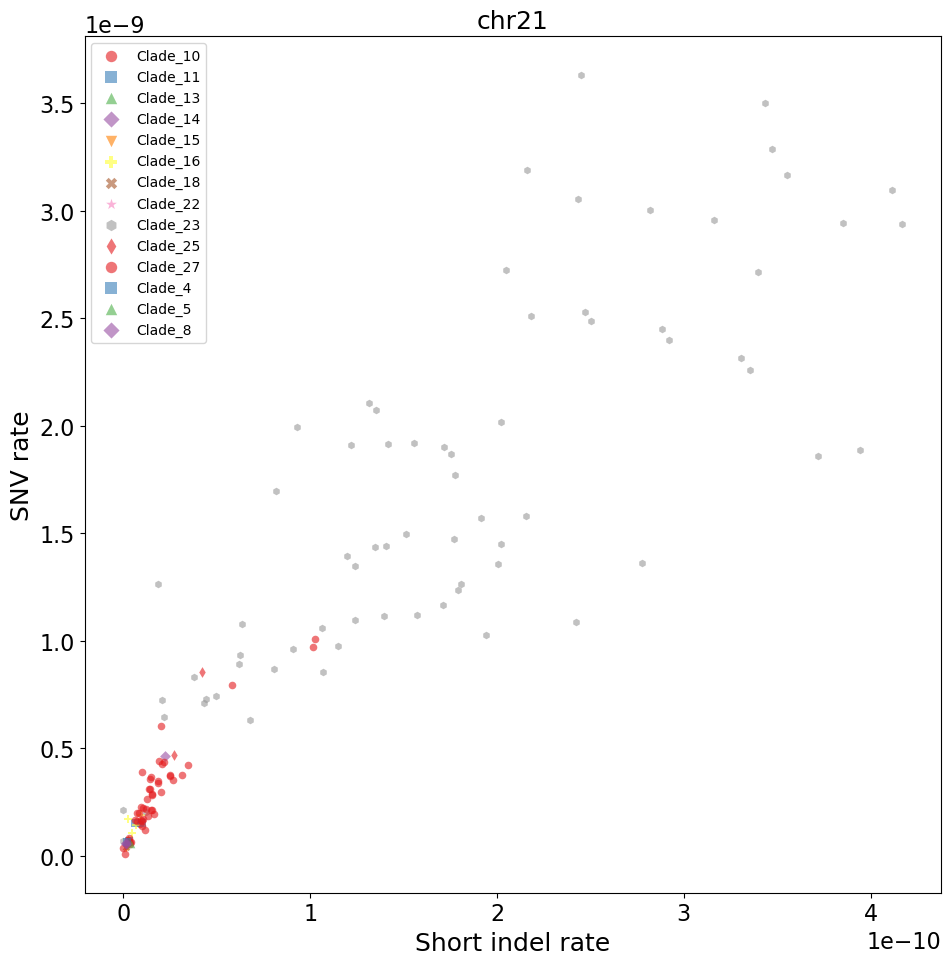

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

chunk = df_plot[df_plot["chr"] == "chr21"]

local_clades = sorted([c for c in chunk["pair_clade"].unique() if c != "cross-clade"])
local_palette = {c: base_palette[i % len(base_palette)] for i, c in enumerate(local_clades)}
local_palette["cross-clade"] = (0, 0, 0)
local_markers = {c: markers[i % len(markers)] for i, c in enumerate(local_clades)}
local_markers["cross-clade"] = "+"

for clade in local_clades + ["cross-clade"]:
    sub = chunk[chunk["pair_clade"] == clade]
    if len(sub) == 0:
        continue
    ax.scatter(sub["n_short_indels_per_aligned_base_per_avg_len"], sub["n_snvs_per_aligned_base_per_avg_len"],
               c=[local_palette[clade]], marker=local_markers[clade],
               s=30, alpha=0.6, linewidth=0, label=clade)

ax.set_title("chr21", fontsize=18)
ax.set_xlabel("Short indel rate")
ax.set_ylabel("SNV rate")
ax.legend(fontsize=10, markerscale=1.5, loc="best")
ax.set_box_aspect(1)

fig.tight_layout()
plt.show()


### Remove chr21 clade 23 samples 

In [15]:
# Non-clade23 pairs for chr21 (used as baseline)
df_other = df_chr21[~df_chr21["both_clade23"]]

snv_mean = df_other["n_snvs_per_aligned_base_per_avg_len"].mean()
snv_std  = df_other["n_snvs_per_aligned_base_per_avg_len"].std()
indel_mean = df_other["n_short_indels_per_aligned_base_per_avg_len"].mean()
indel_std  = df_other["n_short_indels_per_aligned_base_per_avg_len"].std()

print(f"Non-clade23 mean SNV rate:         {snv_mean:.2e} (std: {snv_std:.2e})")
print(f"Non-clade23 mean short indel rate: {indel_mean:.2e} (std: {indel_std:.2e})")

Q1_snv = df_other["n_snvs_per_aligned_base_per_avg_len"].quantile(0.25)
Q3_snv = df_other["n_snvs_per_aligned_base_per_avg_len"].quantile(0.75)
snv_upper = Q3_snv + 1.5 * (Q3_snv - Q1_snv)

Q1_indel = df_other["n_short_indels_per_aligned_base_per_avg_len"].quantile(0.25)
Q3_indel = df_other["n_short_indels_per_aligned_base_per_avg_len"].quantile(0.75)
indel_upper = Q3_indel + 1.5 * (Q3_indel - Q1_indel)

print(f"\nOutlier thresholds (Q3 + 1.5*IQR from non-clade23):")
print(f"  SNV rate   > {snv_upper:.2e}")
print(f"  Indel rate > {indel_upper:.2e}")


Non-clade23 mean SNV rate:         2.50e-10 (std: 2.14e-10)
Non-clade23 mean short indel rate: 1.48e-11 (std: 1.84e-11)

Outlier thresholds (Q3 + 1.5*IQR from non-clade23):
  SNV rate   > 7.60e-10
  Indel rate > 4.06e-11


In [16]:
snv_outliers = df_c23[df_c23["n_snvs_per_aligned_base_per_avg_len"] > snv_upper]
indel_outliers = df_c23[df_c23["n_short_indels_per_aligned_base_per_avg_len"] > indel_upper]

either_outliers = df_c23[
    (df_c23["n_snvs_per_aligned_base_per_avg_len"] > snv_upper) |
    (df_c23["n_short_indels_per_aligned_base_per_avg_len"] > indel_upper)
].sort_values("n_snvs_per_aligned_base_per_avg_len", ascending=False)

print(f"{len(either_outliers)} clade23 pairs are outliers in SNV or short indel rate:")
print(either_outliers[["sample1", "sample2", "n_snvs_per_aligned_base_per_avg_len", "n_short_indels_per_aligned_base_per_avg_len"]].to_string(index=False))

outlier_samples = set(either_outliers["sample1"]) | set(either_outliers["sample2"])
print(f"\n{len(outlier_samples)} unique samples:")
print(sorted(outlier_samples))


66 clade23 pairs are outliers in SNV or short indel rate:
  sample1   sample2  n_snvs_per_aligned_base_per_avg_len  n_short_indels_per_aligned_base_per_avg_len
HG00344.2 HG04184.2                         3.630111e-09                                 2.447266e-10
HG00321.1 HG04184.2                         3.501280e-09                                 3.432627e-10
HG00323.1 HG04184.2                         3.287617e-09                                 3.472835e-10
HG00320.1 HG04184.2                         3.190636e-09                                 2.159077e-10
HG00344.2 HG02559.2                         3.165106e-09                                 3.554397e-10
HG00321.1 HG02559.2                         3.095689e-09                                 4.114524e-10
HG00320.1 HG01786.2                         3.055269e-09                                 2.435359e-10
HG00321.2 HG01934.2                         3.005140e-09                                 2.817319e-10
HG00344.2 HG01934.2     

In [17]:
print(len(df[df["chr"] == "chr21"]))


140


In [18]:
# Get index of outlier pairs
outlier_keys = set(zip(either_outliers["sample1"], either_outliers["sample2"], either_outliers["chr"]))

df_filtered = df[~df.apply(lambda r: (r["sample1"], r["sample2"], r["chr"]) in outlier_keys, axis=1)].copy()

print(f"Original: {len(df)} rows, Filtered: {len(df_filtered)} rows, Removed: {len(df) - len(df_filtered)}")


Original: 4761 rows, Filtered: 4695 rows, Removed: 66


/data/tmp/ipykernel_3742051/4229291703.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_3742051/4229291703.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/data/tmp/ipykernel_3742051/4229291703.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_3742051/4229291703.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/data/tmp/ipykernel_3742051/4229291703.py:31: FutureWarning: 

Passing `palette` without assigning `hue`

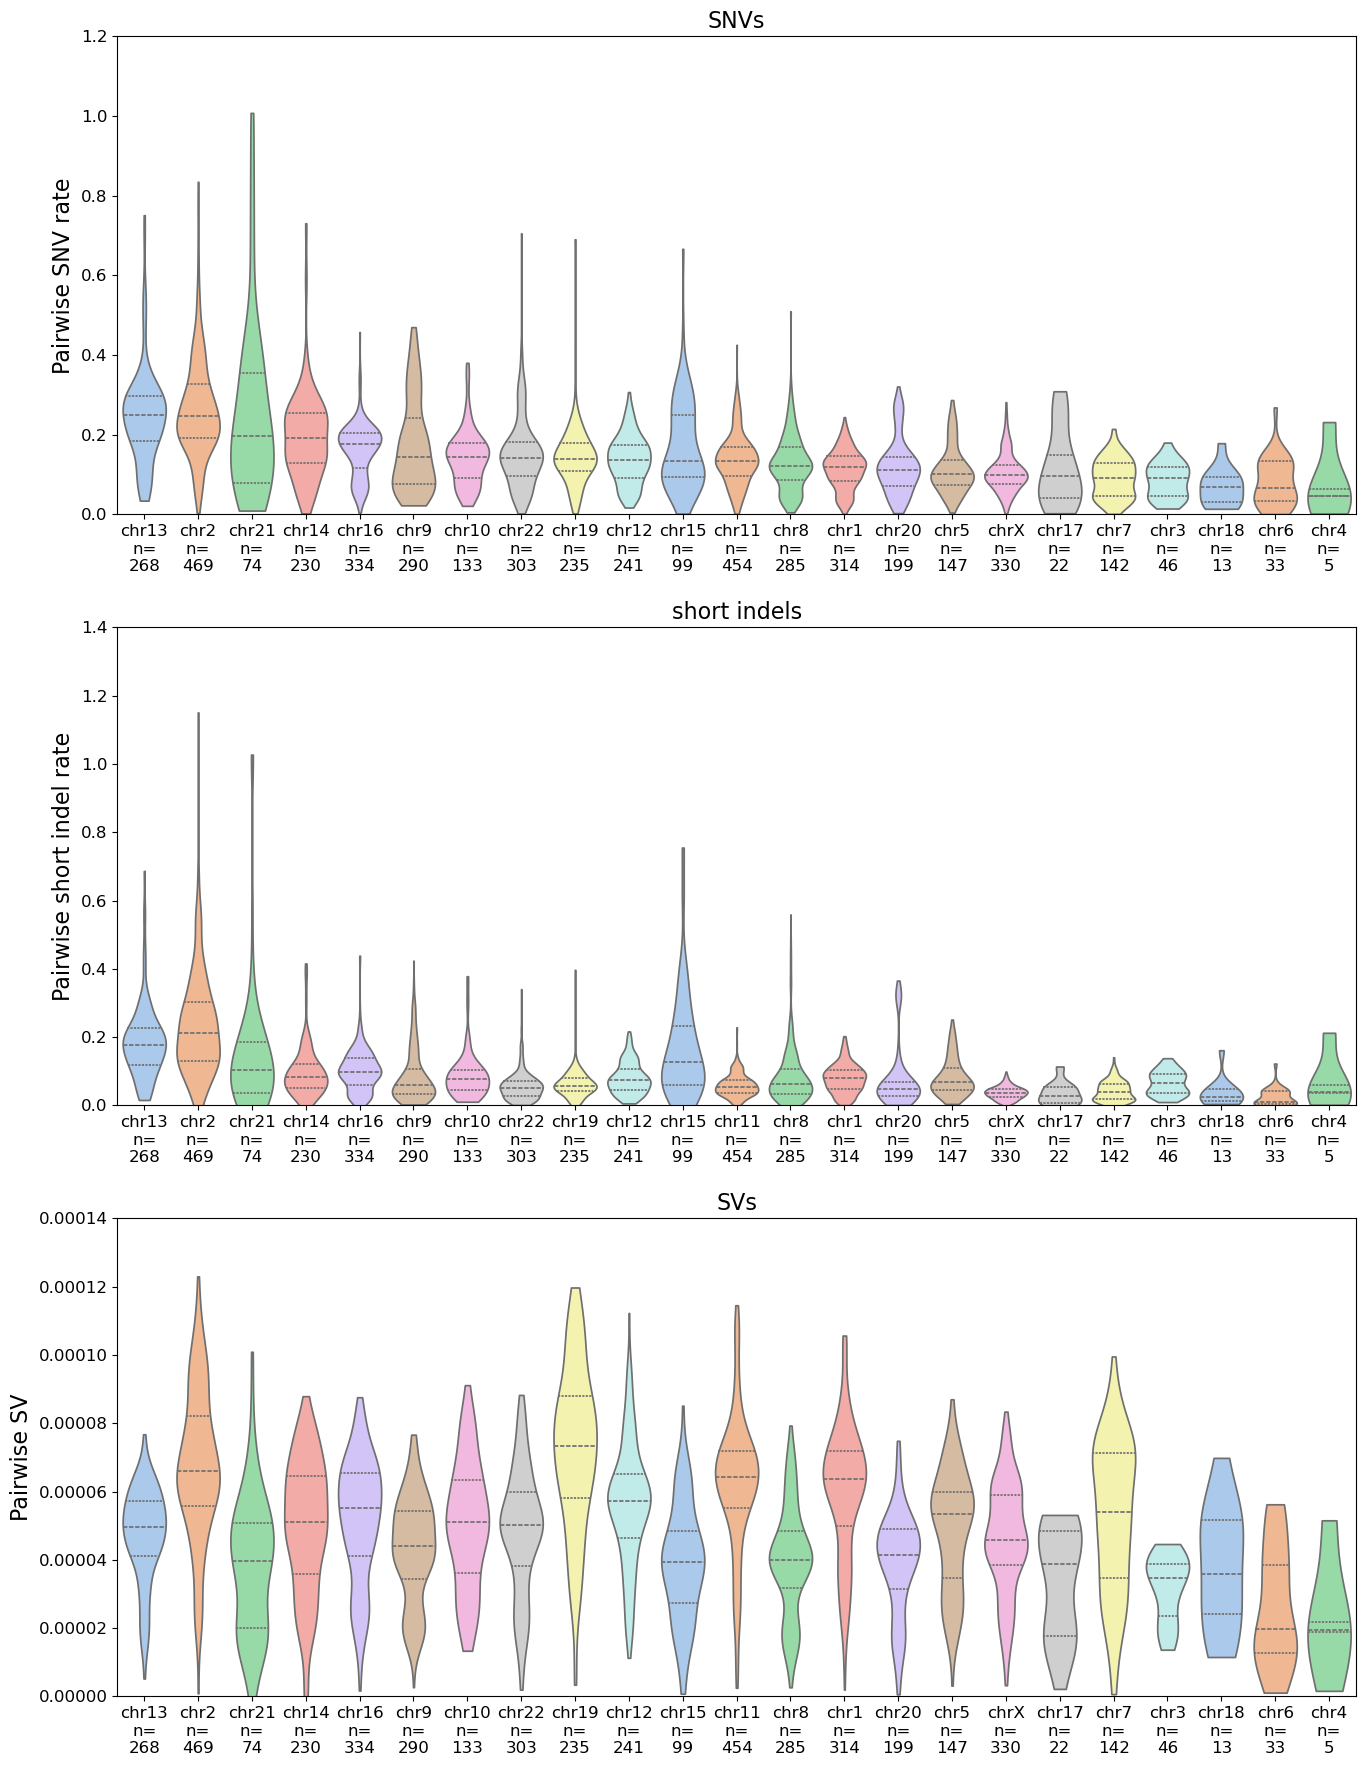

In [34]:
from matplotlib.ticker import ScalarFormatter
import math 

metrics = [
    "n_snvs_per_aligned_base_per_avg_len",
    "n_short_indels_per_aligned_base_per_avg_len",
    "n_svs_per_avg_len",
]
titles = ["SNVs",
          "short indels",
          "SVs"]
y_labels = ["Pairwise SNV rate",
          "Pairwise short indel rate",
          "Pairwise SV"]

# Define shared chromosome order by median SNV rate
chr_order_shared = (df_plot.groupby("chr")["n_snvs_per_aligned_base_per_avg_len"]
                    .median()
                    .sort_values(ascending=False)
                    .index.tolist())

# Define shared color palette per chromosome
chr_palette = dict(zip(chr_order_shared, sns.color_palette("pastel", len(chr_order_shared))))

chr_counts = df_plot["chr"].value_counts()
chr_labels = [f"{c}\nn=\n{chr_counts[c]}" for c in chr_order_shared]

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, metric, title, y_lab in zip(axes, metrics, titles,y_labels):
    sns.violinplot(
        data=df_plot,
        x="chr",
        y=metric,
        order=chr_order_shared,
        inner="quartile",
        cut=0,
        scale="width",
        palette=chr_palette,
        ax=ax,
    )
    ax.set_xticks(range(len(chr_order_shared)))
    ax.set_xticklabels(chr_labels, rotation=0, fontsize=12)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel(y_lab, fontsize=16)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)
    ax.yaxis.get_offset_text().set_visible(True)
    ax.yaxis.get_offset_text().set_fontsize(12)


    ax.set_ylim(bottom=0)
    


axes[-1].set_xlabel("")

fig.tight_layout()
for ax in axes:
    ax.yaxis.offsetText.set_visible(True)
    ax.yaxis.offsetText.set_fontsize(12)
plt.show()



In [10]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "/private/groups/patenlab/mira/centrolign/github/centrolign_analysis/analysis_notes/release2_QC_v2/plots/sv_vs_snv_rate_per_chrom.pdf"

chrom_list = sorted(df_plot["chr"].unique(), key=lambda c: int(c.replace("chr", "")) if c.replace("chr", "").isdigit() else 100 + ord(c[-1]))
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "d"]

with PdfPages(pdf_path) as pdf:
    for chrom in chrom_list:
        fig, ax = plt.subplots(figsize=(8, 8))
        chunk = df_plot[df_plot["chr"] == chrom]

        local_clades = sorted([c for c in chunk["pair_clade"].unique() if c != "cross-clade"])
        local_palette = {c: base_palette[i % len(base_palette)] for i, c in enumerate(local_clades)}
        local_palette["cross-clade"] = (0, 0, 0)
        local_markers = {c: markers[i % len(markers)] for i, c in enumerate(local_clades)}
        local_markers["cross-clade"] = "+"

        for clade in local_clades + ["cross-clade"]:
            sub = chunk[chunk["pair_clade"] == clade]
            if len(sub) == 0:
                continue
            ax.scatter(sub["n_svs_per_avg_len"], sub["n_snvs_per_aligned_base_per_avg_len"],
                       c=[local_palette[clade]], marker=local_markers[clade],
                       s=30, alpha=0.6, linewidth=0, label=clade)

        ax.set_title(chrom, fontsize=18)
        ax.set_xlabel("SV rate")
        ax.set_ylabel("SNV rate")
        ax.legend(fontsize=10, markerscale=1.5, loc="best")
        ax.set_box_aspect(1)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved to {pdf_path}")


Saved to /private/groups/patenlab/mira/centrolign/github/centrolign_analysis/analysis_notes/release2_QC_v2/plots/sv_vs_snv_rate_per_chrom.pdf


### Plot SNV rates against cenhap distances, colored by clade 

In [11]:
### cenhap matrices filepaths

cenhap_matrices = ["/chr11/no_recombinants/HPRC_chr11_50650000_51023358_54476419_54808189_no_recomb_het449_m_final_dgp.m",
"/chr10/no_recombinants/HPRC_chr10_39415000_39633793_41926237_42547087_42982864_42995500_no_recomb_m_final_dgp.m",
"/chr12_prelim/HPRC_chr12_34544731_34593492_37202490_37285321_het60_m_hprc_dgp_rnj.m",
"/chr17_prelim/HPRC_chr17_23278614_23433372_27571319_27700000_het114_m_hprc_dgp.m",
"/chr4/no_recomb/HPRC_chr4_49185000_49705154_55303192_55475000_no_recomb_het449_m_final_dgp.m",
"/chr6_prelim/standard/HPRC_chr6_58200000_58286706_61058390_61123742_het70_m_hprc_dgp_rnj.m"]

cenhap_matrices = ["/private/groups/patenlab/mira/centrolign/annotations/hprc_cenhap_trees_12042025"+item for item in cenhap_matrices]

In [12]:
## This function reads in the cenhap distance matrices to a pandas dataframe 

def load_matrix(file):
    # Read all lines except first
    with open(file) as f:
        lines = f.readlines()[1:]

    data = []
    sample_names = []
    for line in lines:
        parts = line.strip().split()
        sample = parts[0]
        values = list(map(float, parts[1:]))
        data.append(values)
        sample_names.append(sample)

    # Create dataframe
    df = pd.DataFrame(data, index=sample_names, columns=sample_names)

    return df


def to_long_format(df):
    df.index.name = "sample1"

    long = df.stack().rename("cenhap_dist").reset_index()

    # The second column (index 1) is always the sample2 column
    long = long.rename(columns={long.columns[1]: "sample2"})

    return long



# -------------------------
# Main loop
# -------------------------

all_long = []  # <-- FIXED: create the correct list

for f in cenhap_matrices:
    mat = load_matrix(f)
    long = to_long_format(mat)
    long["source_file"] = f
    all_long.append(long)  # <-- FIXED: append to correct list

cenhap_dists = pd.concat(all_long, ignore_index=True)

# Add chromosome extracted from the filepath
cenhap_dists["chr"] = cenhap_dists["source_file"].str.extract(r"(chr[0-9XYM]+)")

print(cenhap_dists.head())

   sample1    sample2  cenhap_dist  \
0  CHM13.0    CHM13.0     0.000000   
1  CHM13.0  HG00097.1     0.002401   
2  CHM13.0  HG00097.2     0.002408   
3  CHM13.0  HG00099.1     0.002405   
4  CHM13.0  HG00126.1     0.002405   

                                         source_file    chr  
0  /private/groups/patenlab/mira/centrolign/annot...  chr11  
1  /private/groups/patenlab/mira/centrolign/annot...  chr11  
2  /private/groups/patenlab/mira/centrolign/annot...  chr11  
3  /private/groups/patenlab/mira/centrolign/annot...  chr11  
4  /private/groups/patenlab/mira/centrolign/annot...  chr11  


Merged: 1516 pairs across 6 chromosomes
After outlier removal: 1424 pairs


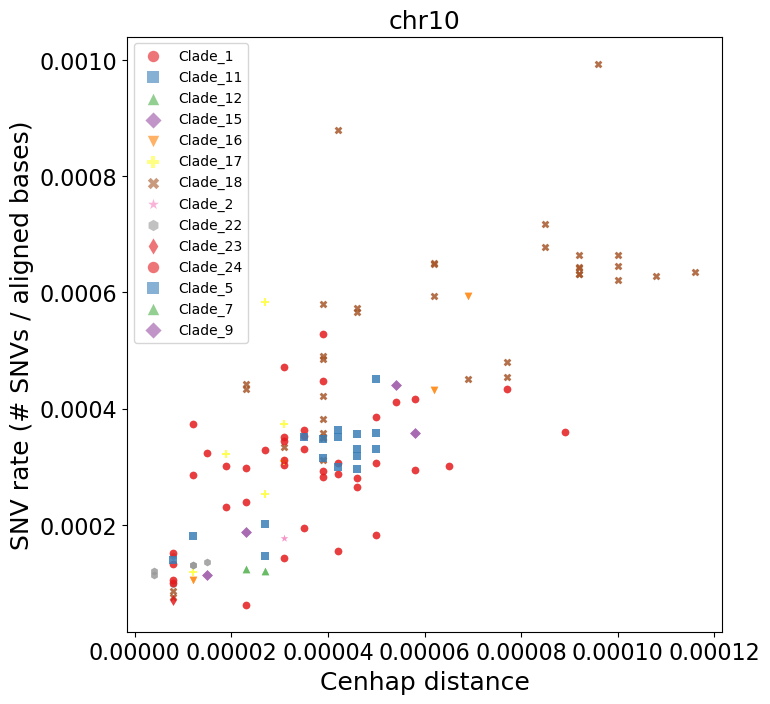

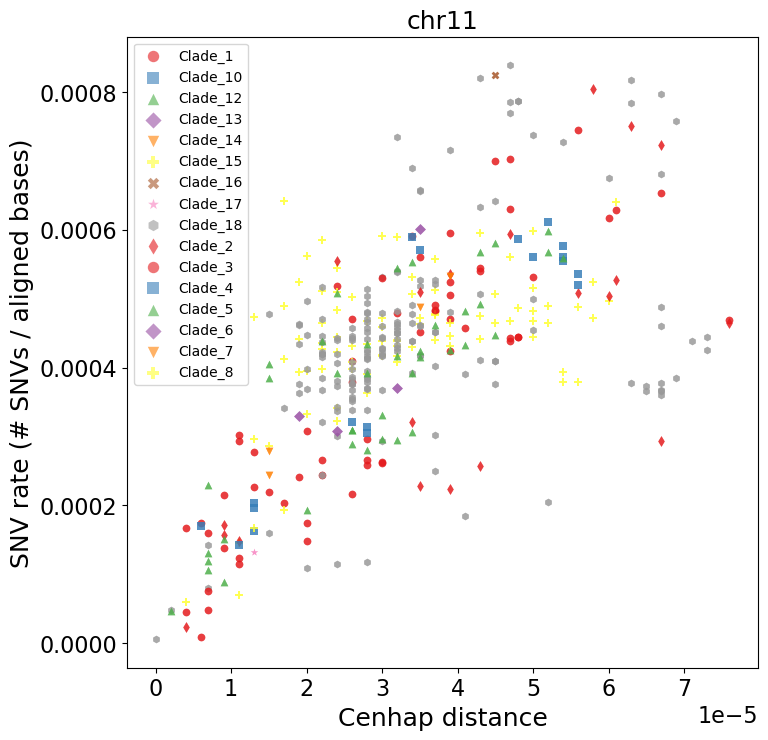

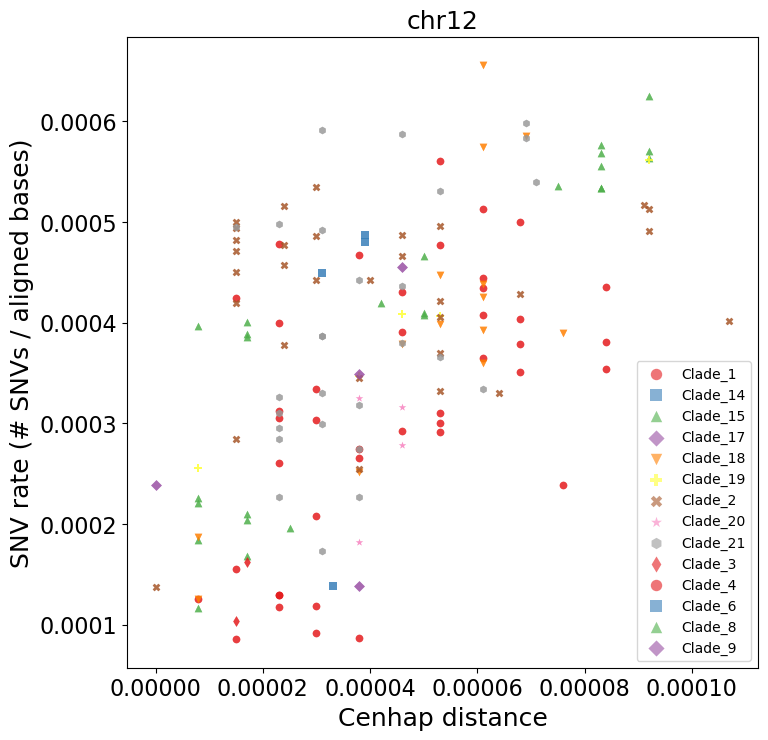

In [15]:
# Create order-independent pair key in both dataframes
df["pair_key"] = df.apply(lambda r: tuple(sorted([r["sample1"], r["sample2"]])), axis=1)
df["pair_key_chr"] = list(zip(df["pair_key"], df["chr"]))

cenhap_dists["pair_key"] = cenhap_dists.apply(lambda r: tuple(sorted([r["sample1"], r["sample2"]])), axis=1)
cenhap_dists["pair_key_chr"] = list(zip(cenhap_dists["pair_key"], cenhap_dists["chr"]))

# Keep only pairs common to both
common_keys = set(df["pair_key_chr"]) & set(cenhap_dists["pair_key_chr"])

df_common = df[df["pair_key_chr"].isin(common_keys)].copy()
cenhap_common = cenhap_dists[cenhap_dists["pair_key_chr"].isin(common_keys)].copy()

# Merge
merged = df_common.merge(
    cenhap_common[["pair_key", "chr", "cenhap_dist"]],
    on=["pair_key", "chr"],
    how="inner"
)
print(f"Merged: {len(merged)} pairs across {merged['chr'].nunique()} chromosomes")

merged = remove_outliers(merged, value_col="cenhap_dist", group_col="chr")
print(f"After outlier removal: {len(merged)} pairs")

# Plot per chromosome
chrom_list = sorted(merged["chr"].unique(),
                    key=lambda c: int(c[3:]) if c[3:].isdigit() else 100 + ord(c[-1]))

chrom_list = ["chr10", "chr11", "chr12"]


for chrom in chrom_list:
    fig, ax = plt.subplots(figsize=(8, 8))
    chunk = merged[merged["chr"] == chrom]

    local_clades = sorted([c for c in chunk["pair_clade"].unique() if c != "cross-clade"])
    local_palette = {c: base_palette[i % len(base_palette)] for i, c in enumerate(local_clades)}
    local_palette["cross-clade"] = (0, 0, 0)
    local_markers = {c: markers[i % len(markers)] for i, c in enumerate(local_clades)}
    local_markers["cross-clade"] = "+"

    for clade in local_clades + ["cross-clade"]:
        sub = chunk[chunk["pair_clade"] == clade]
        if len(sub) == 0:
            continue
        ax.scatter(sub["cenhap_dist"], sub["n_snvs_per_aligned_base"],
                   c=[local_palette[clade]], marker=local_markers[clade],
                   s=30, alpha=0.6, linewidth=0, label=clade)

    ax.set_title(chrom, fontsize=18)
    ax.set_xlabel("Cenhap distance")
    ax.set_ylabel("SNV rate (# SNVs / aligned bases)")
    ax.legend(fontsize=10, markerscale=1.5, loc="best")
    ax.set_box_aspect(1)

    plt.tight_layout()
    plt.show()
